In [ ]:
import numpy as np
from scipy.optimize import minimize

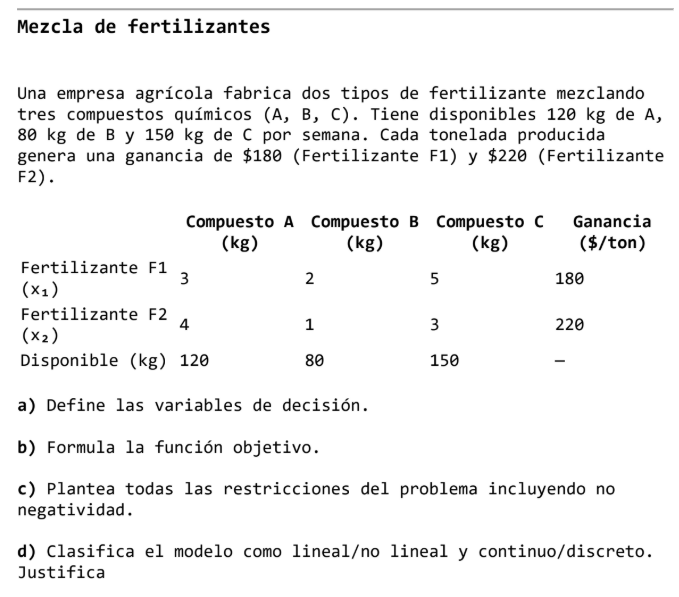

In [ ]:
import numpy as np
from scipy.optimize import linprog

"""
Usamos el metodo LP simplex pues el problema es lineal y continuo
"""
# Datos de la función objetivo
# Max f(x1,x2) = 180x1 + 220x2  ---> Min -f(x1,x2) = -180x1 - 220x2
"""
 Multiplicamos por -1 porque queremos maximizar la funcion ganancias y esto es igual que  minimizar el inverso de esta funcion.
"""
c = np.array([-180, -220])

# Coeficientes de las restricciones(Cantidad de cada compuesto usada en la produccion de 1T de fertilizante), lado Izquierdo, lo dice la documentacion de scipy
# 3x1 + 4x2 <= 120
# 2x1 + x2  <= 80
# 5x1 + 3x2 <= 150
A_ub = np.array([
    [3, 4],
    [2, 1],
    [5, 3]
])

# Límites de las restricciones(Cantidad de compuesto disponible), lado Derecho, lo dice la documentacion de scipy
b_ub = np.array([120, 80, 150])

# Restricciones de no negatividad x1 , x2 >= 0
limites = [(0, None), (0, None)]

# Resolver usando el método Simplex, por ser lineal y continuo el problema
resultado = linprog(
    c,
    A_ub=A_ub,
    b_ub=b_ub,
    bounds=limites,
    method='simplex'  # Aquí especificamos el uso del algoritmo Simplex
)

# Extraer y mostrar los resultados
print(" = " * 45)
print("Problema de mezcla de fertilizantes")
print(" = " * 45)

x1_opt = resultado.x[0]
x2_opt = resultado.x[1]
    # Volvemos a multiplicar por -1 la función objetivo para obtener la ganancia real
ganancia_max = -resultado.fun

print(f"Producción óptima F1 (x1): {x1_opt:.2f} toneladas")
print(f"Producción óptima F2 (x2): {x2_opt:.2f} toneladas")
print(f"Ganancia máxima (Z): ${ganancia_max:.2f}")
print("Consumo de compuestos en el punto óptimo:")
print(f"Compuesto A: {3*x1_opt + 4*x2_opt:.2f} kg / 120 kg")
print(f"Compuesto B: {2*x1_opt + x2_opt:.2f} kg / 80 kg")
print(f"Compuesto C: {5*x1_opt + 3*x2_opt:.2f} kg / 150 kg")


 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
Problema de mezcla de fertilizantes
 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
Producción óptima F1 (x1): 21.82 toneladas
Producción óptima F2 (x2): 13.64 toneladas
Ganancia máxima (Z): $6927.27
Consumo de compuestos en el punto óptimo:
Compuesto A: 120.00 kg / 120 kg
Compuesto B: 57.27 kg / 80 kg
Compuesto C: 150.00 kg / 150 kg


/tmp/ipykernel_5860/64114755.py:31: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  resultado = linprog(


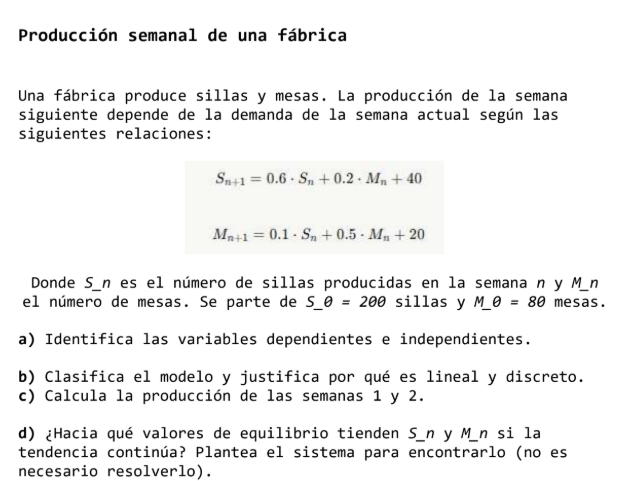

In [ ]:
# Variable de decision
n = 5# 5 es el número de semanas escogido al azar y es pequeño para no tardar mucho
#funciones objetivo
def s_n1(n, S_n, M_n):
    return  0.6 * S_n + 0.2 * M_n + 40
def m_n1(n, S_n, M_n):
    return  0.1 * S_n + 0.5 * M_n + 20

#Valores iniciales
S_n = 200
M_n = 80
print(f"Semana 0: Sillas = {S_n:.1f}, Mesas = {M_n:.1f}")



for n in range(1, n + 1):

    S_siguiente = s_n1(n,S_n,M_n)
    M_siguiente = m_n1(n,S_n,M_n)
    S_n = S_siguiente
    M_n = M_siguiente

    print(f"Semana {n}: Sillas = {S_n:.1f}, Mesas = {M_n:.1f}")



Semana 0: Sillas = 200.0, Mesas = 80.0
Semana 1: Sillas = 176.0, Mesas = 80.0
Semana 2: Sillas = 161.6, Mesas = 77.6
Semana 3: Sillas = 152.5, Mesas = 75.0
Semana 4: Sillas = 146.5, Mesas = 72.7
Semana 5: Sillas = 142.4, Mesas = 71.0


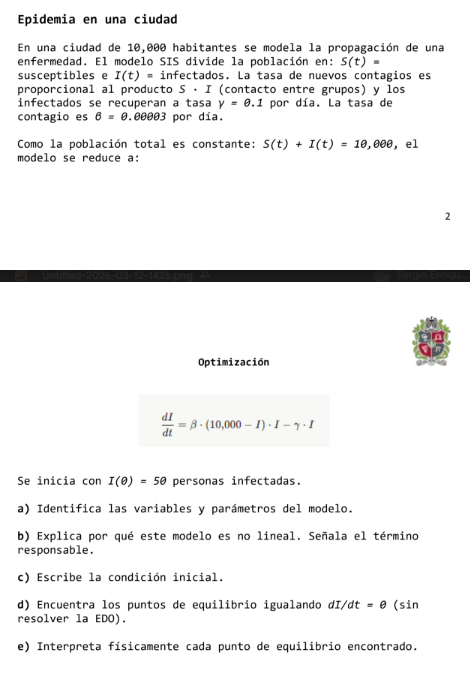

 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
 Simulación del Modelo SIS
 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
Infectados en el día 0: 50
Infectados en el día 200: 6666


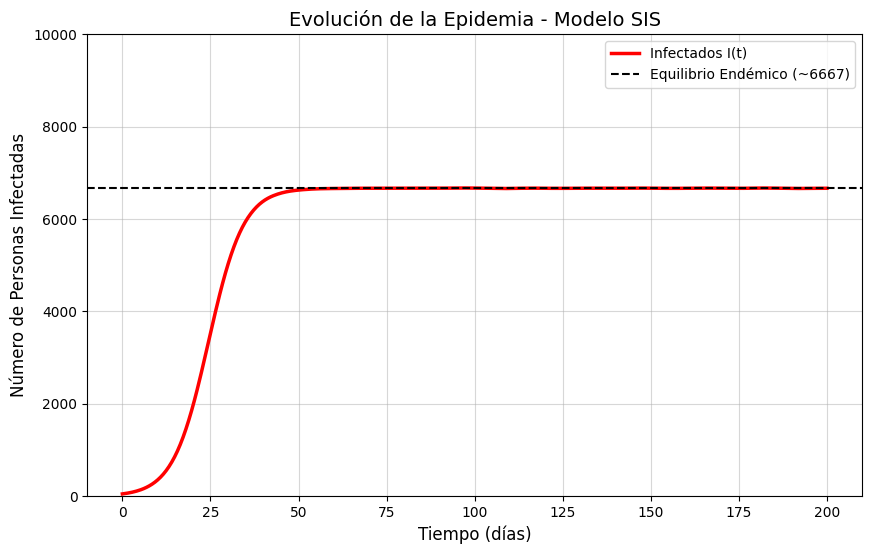

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# 1. Definición de Parámetros
N = 10000          # Población total constante
beta = 0.00003     # Tasa de contagio
gamma = 0.1        # Tasa de recuperación
I0 = [50]          # Condición inicial: 50 infectados en t=0

# 2. Definición de la Ecuación Diferencial Ordinaria (EDO)
def modelo_sis(t, I):
    dI_dt = beta * (N - I) * I - gamma * I
    return dI_dt

# 3. Configuración del tiempo de simulación
t_inicio = 0
t_fin = 200  # 200 días
t_span = (t_inicio, t_fin)
t_eval = np.linspace(t_inicio, t_fin, 500) # Genera 500 puntos de tiempo para una curva suave

# Resolución de la EDO
resultado = solve_ivp(modelo_sis, t_span, I0, t_eval=t_eval)

# Extraemos el tiempo y los valores de I(t) calculados
tiempo = resultado.t
infectados = resultado.y[0]

print(" = " * 20)
print(" Simulación del Modelo SIS")
print(" = " * 20)
print(f"Infectados en el día 0: {infectados[0]:.0f}")
print(f"Infectados en el día {t_fin}: {infectados[-1]:.0f}")

plt.figure(figsize=(10, 6))
plt.plot(tiempo, infectados, label='Infectados I(t)', color='red', linewidth=2.5)

# Añadimos una línea punteada para mostrar el límite teórico (equilibrio endémico)
equilibrio_endemico = 6666.67
plt.axhline(y=equilibrio_endemico, color='black', linestyle='--',
            label=f'Equilibrio Endémico (~{equilibrio_endemico:.0f})')

plt.title('Evolución de la Epidemia - Modelo SIS', fontsize=14)
plt.xlabel('Tiempo (días)', fontsize=12)
plt.ylabel('Número de Personas Infectadas', fontsize=12)
plt.ylim(0, 10000) # Límite del eje Y hasta la población total
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
 Simulación de Pesca (P_0 = 400)
 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
Año 0: 400.00 peces
Año 1: 416.00 peces
Año 2: 433.18 peces
Año 30: 719.52 peces


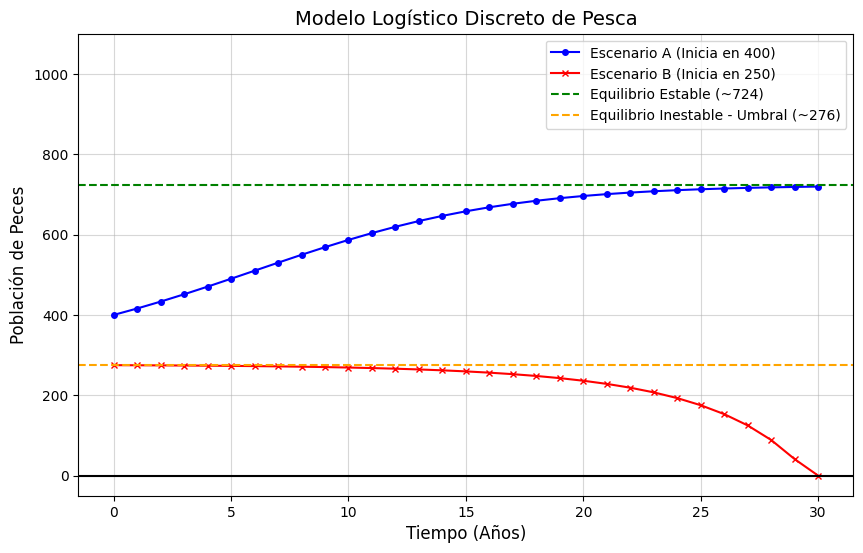

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definición de Parámetros
K = 1000      # Capacidad de carga
r = 0.4       # Tasa de crecimiento intrínseca
H = 80        # Cuota de pesca anual
años = 30     # Número de años a simular, solo queremos ver el desarrollo del modelo, escojemos un valor cualquiera que nos permita esto
# Puntos de equilibrio calculados
eq_estable = 723.61
eq_inestable = 276.39
# 2. Función para simular el modelo discreto
def simular_poblacion(P_inicial, años):
    P = [P_inicial]
    for n in range(años):
        P_n = P[-1]
        P_siguiente = P_n + r * P_n * (1 - P_n / K) - H
        P_siguiente = max(0, P_siguiente)
        P.append(P_siguiente)

    return P
tiempo = np.arange(años + 1) # Eje X: del año 0 al 30
# Escenario A: Población inicial = 400
P_escenario_A = simular_poblacion(400, años)
# Escenario B: Población inicial = Por debajo del umbral crítico
P_escenario_B = simular_poblacion(275, años)
# Mostramos los primeros resultados numéricos del Escenario A
print(" = " * 20)
print(" Simulación de Pesca (P_0 = 400)")
print(" = " * 20)
print(f"Año 0: {P_escenario_A[0]:.2f} peces")
print(f"Año 1: {P_escenario_A[1]:.2f} peces")
print(f"Año 2: {P_escenario_A[2]:.2f} peces")
print(f"Año {años}: {P_escenario_A[-1]:.2f} peces")

# 4. Visualización de los resultados
plt.figure(figsize=(10, 6))

# Graficamos ambos escenarios
plt.plot(tiempo, P_escenario_A, label='Escenario A ', color='blue', marker='o', markersize=4)
plt.plot(tiempo, P_escenario_B, label='Escenario E ', color='red', marker='x', markersize=4)

# Añadimos líneas teóricas de equilibrio
plt.axhline(y=eq_estable, color='green', linestyle='--', label=f'Equilibrio Estable (~{eq_estable:.0f})')
plt.axhline(y=eq_inestable, color='orange', linestyle='--', label=f'Equilibrio Inestable (~{eq_inestable:.0f})')
plt.axhline(y=0, color='black', linestyle='-') # Línea de extinción de la poblacion

# Detalles del gráfico
plt.title('Modelo Logístico Discreto de Pesca', fontsize=14)
plt.xlabel('Tiempo (Años)', fontsize=12)
plt.ylabel('Población de Peces', fontsize=12)
plt.ylim(-50, 1100) # Límite del eje Y para ver bien la gráfica
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()